# Wasserstein K-Means

## Market regime detection for one index or stock

In [1]:
import sys
sys.path.append("..")

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [28]:
%load_ext autoreload
%autoreload 2
    
from market_regime_detection.data import (
    load_yf_data,
    compute_log_returns
)

from market_regime_detection.wasserstein_univariate import (
    split_array_into_windows,
    wasserstein_k_means,
    get_corrected_assignments
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading data

In [5]:
TICKER = "^GSPC"

In [6]:
date_from = "2016-01-01"
date_to = "2026-01-01"

In [7]:
market_data = load_yf_data(
    tickers=TICKER, date_from=date_from, date_to=date_to
)

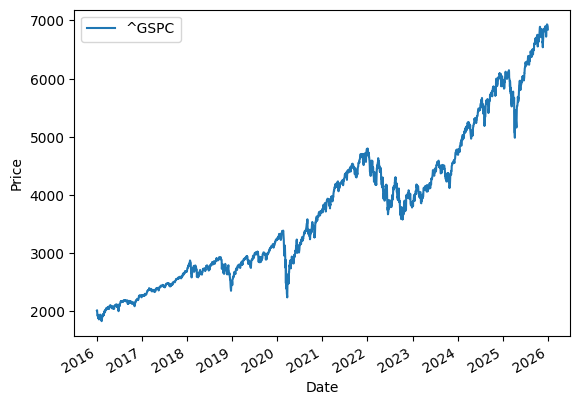

In [8]:
market_data.plot()
plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

Exactly 252 trading days on average

In [9]:
market_data.index.year.value_counts()

Date
2020    253
2016    252
2021    252
2019    252
2024    252
2017    251
2018    251
2022    251
2023    250
2025    250
Name: count, dtype: int64

Compute log-returns

In [10]:
market_returns = market_data.apply(compute_log_returns, axis=0)
market_returns = market_returns.set_index(market_data.index[1:].floor("d"))

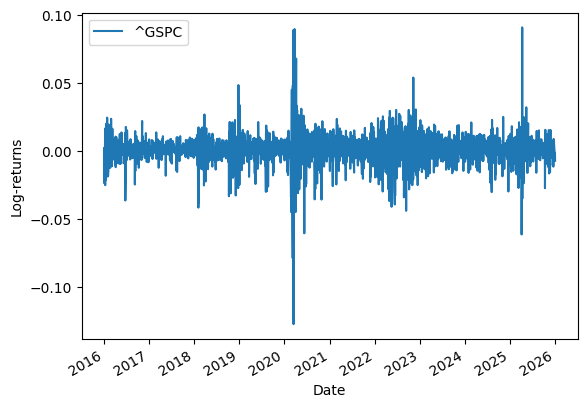

In [11]:
market_returns.plot()
plt.ylabel("Log-returns")
plt.xlabel("Date")
plt.show()

## Clusterization

In [12]:
WINDOW_LENGTH_DAYS = 40   # ~ 2 months

In [13]:
data_for_clustering = split_array_into_windows(
    market_returns = market_returns[TICKER].to_numpy(), 
    window_shape=WINDOW_LENGTH_DAYS
)

- 2 clusters - bull and bear market
- 3 clusters - bull / neutral / stress
- 4+ clusters - volatility clustering / finer market regimes

In [14]:
NUMBER_OF_CLUSTERS = 2

In [15]:
assignments, clusters, centroids = wasserstein_k_means(
    chunks=data_for_clustering,
    n_clusters=NUMBER_OF_CLUSTERS,
    max_iter=50
)

In [37]:
np.unique(assignments, return_counts=True)

(array([0, 1]), array([1630,  844]))

## Visualization

In [52]:
corrected_assignments = get_corrected_assignments(
    assignments=assignments, window_shape=WINDOW_LENGTH_DAYS
)

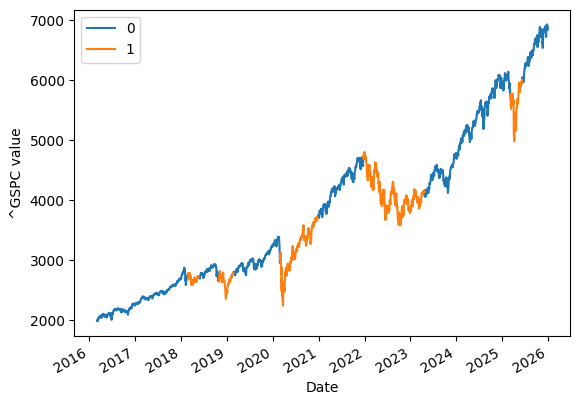

In [59]:
(
    market_data.iloc[WINDOW_LENGTH_DAYS:, :]
    .assign(cluster=corrected_assignments)
    .reset_index()
    .pivot(
        index="Date",
        columns="cluster",
        values=TICKER
    )
    .plot()
)

plt.xlabel("Date")
plt.ylabel(f"{TICKER} value")
plt.legend()
plt.show()

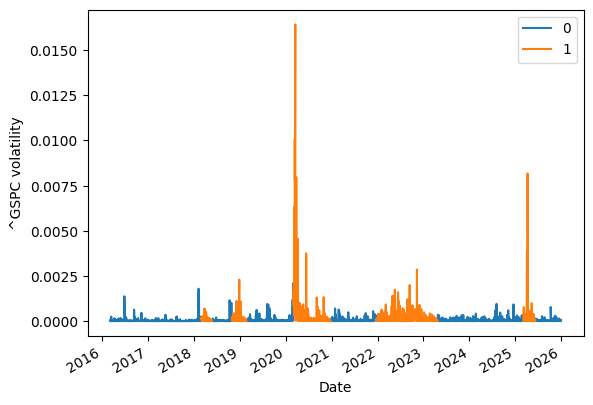

In [68]:
(
    market_returns.iloc[WINDOW_LENGTH_DAYS-1:, :]
    .apply(lambda x: (x - np.mean(x))**2)
    .assign(cluster=corrected_assignments)
    .reset_index()
    .pivot(
        index="Date",
        columns="cluster",
        values=TICKER
    )
    .plot()
)

plt.xlabel("Date")
plt.ylabel(f"{TICKER} volatility")
plt.legend()
plt.show()